# 03 — Bond Markets & Rates

**Chain position:** Macro → Risk → `Rates` → Global Equity → India → Companies

The bond market usually moves first. It prices growth, inflation and policy in one
instrument, and equity markets tend to follow rather than lead it. This notebook reads
the full US Treasury curve, decomposes its movement, and then does what it honestly can
on the India leg.

### A note on sources, stated up front

**FRED is dead for this project.** All nine series tested timed out, twice. The
replacement is better rather than merely adequate: the US Treasury publishes the
**entire par yield curve — 1M through 30Y — daily as CSV**, where FRED would have given
a handful of separate series.

**India has no comparable public yield feed here.** NSE's `allIndices` carries seven
G-Sec indices, but their `pe`, `pb` and `dy` fields are all zero — verified live. They
publish **index levels, not yields.** So:

- The US leg below is real yields, in percent.
- The India leg is **implied yield *change*, derived from index price moves and modified
  duration.** It gives direction and rough magnitude, not a level.
- An India–US *spread level* is therefore not computed. Comparing the two as changes is
  defensible; inventing an India yield level from a return series would not be.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard,
                 indicators as ind, fundamentals as fnd, score, viz)

# Set REFRESH = True to force a live re-fetch of every source, ignoring the cache.
REFRESH = False
mkt.bootstrap(refresh=REFRESH)

mkt v1.0.0 | run 2026-09-09 10:46 | REFRESH=False | cache=G:\stock market analysis\data\cache


## 1. The US curve today, and where it was

The full term structure, compared against itself 1 month, 3 months and 1 year ago. How
the curve *changed shape* says more than any single tenor: a parallel shift is a
repricing of the policy path, a steepening or flattening is a repricing of the cycle.

In [2]:
curve = fetch.treasury_curve(years_back=config.TREASURY_YEARS_BACK)
tenors = [t for t in config.TREASURY_TENORS if t in curve.columns]
curve = curve[tenors].sort_index()
print(f"US Treasury curve: {curve.shape[0]:,} daily observations x {len(tenors)} tenors")
print(f"Latest: {curve.index[-1].date()}  |  earliest: {curve.index[0].date()}")

def asof(days_back):
    target = curve.index[-1] - pd.Timedelta(days=days_back)
    sub = curve.loc[:target]
    return sub.iloc[-1] if len(sub) else pd.Series(dtype=float)

snap = pd.DataFrame({
    "today": curve.iloc[-1],
    "1m ago": asof(30), "3m ago": asof(91), "1y ago": asof(365),
})
snap["chg 1m (bp)"] = (snap["today"] - snap["1m ago"]) * 100
snap["chg 3m (bp)"] = (snap["today"] - snap["3m ago"]) * 100
snap["chg 1y (bp)"] = (snap["today"] - snap["1y ago"]) * 100
display(snap.round(2))

US Treasury curve: 1,421 daily observations x 14 tenors
Latest: 2026-09-08  |  earliest: 2021-01-04


,today,1m ago,3m ago,1y ago,chg 1m (bp),chg 3m (bp),chg 1y (bp)
1 Mo,3.81,3.79,3.69,4.26,2.00,12.00,-45.00
1.5 Month,3.88,3.79,3.69,4.23,9.00,19.00,-35.00
2 Mo,3.91,3.83,3.71,4.21,8.00,20.00,-30.00
3 Mo,3.94,3.87,3.79,4.10,7.00,15.00,-16.00
4 Mo,4.02,3.89,3.79,4.04,13.00,23.00,-2.00
6 Mo,4.00,3.96,3.82,3.84,4.00,18.00,16.00
1 Yr,4.15,4.01,3.90,3.64,14.00,25.00,51.00
2 Yr,4.39,4.19,4.13,3.49,20.00,26.00,90.00
3 Yr,4.44,4.25,4.16,3.47,19.00,28.00,97.00
5 Yr,4.57,4.35,4.26,3.57,22.00,31.00,100.00


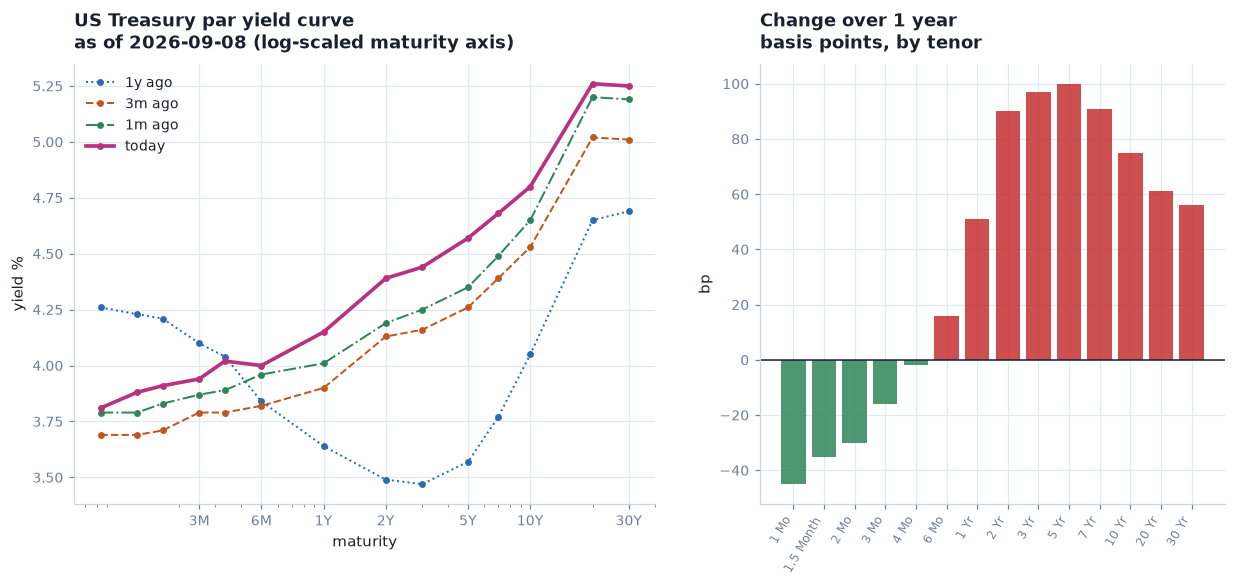

In [3]:
x = [config.TENOR_YEARS[t] for t in tenors]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 5.2),
                             gridspec_kw={"width_ratios": [1.25, 1]})
for col, style, lw in [("1y ago", ":", 1.3), ("3m ago", "--", 1.3),
                       ("1m ago", "-.", 1.3), ("today", "-", 2.4)]:
    a1.plot(x, snap[col].values, style, lw=lw, marker="o", ms=3.5, label=col)
a1.set_xscale("log")
a1.set_xticks([0.25, 0.5, 1, 2, 5, 10, 30])
a1.set_xticklabels(["3M", "6M", "1Y", "2Y", "5Y", "10Y", "30Y"])
viz.title(a1, "US Treasury par yield curve",
          f"as of {curve.index[-1].date()} (log-scaled maturity axis)")
a1.set_ylabel("yield %"); a1.set_xlabel("maturity"); a1.legend()

a2.bar(range(len(tenors)), snap["chg 1y (bp)"].values,
       color=[viz.NEG if v > 0 else viz.POS for v in snap["chg 1y (bp)"]], alpha=0.85)
a2.set_xticks(range(len(tenors)))
a2.set_xticklabels(tenors, rotation=60, ha="right", fontsize=8)
a2.axhline(0, color=viz.INK, lw=1)
viz.title(a2, "Change over 1 year", "basis points, by tenor")
a2.set_ylabel("bp")
viz.save(fig, "03_us_curve"); plt.show()

## 2. Slope and inversion

The curve's slope is the cycle indicator. An inverted curve — short rates above long
rates — has preceded every US recession in the modern record, though with a long and
variable lag. What matters for positioning is not only *whether* it is inverted but
which direction it is moving.

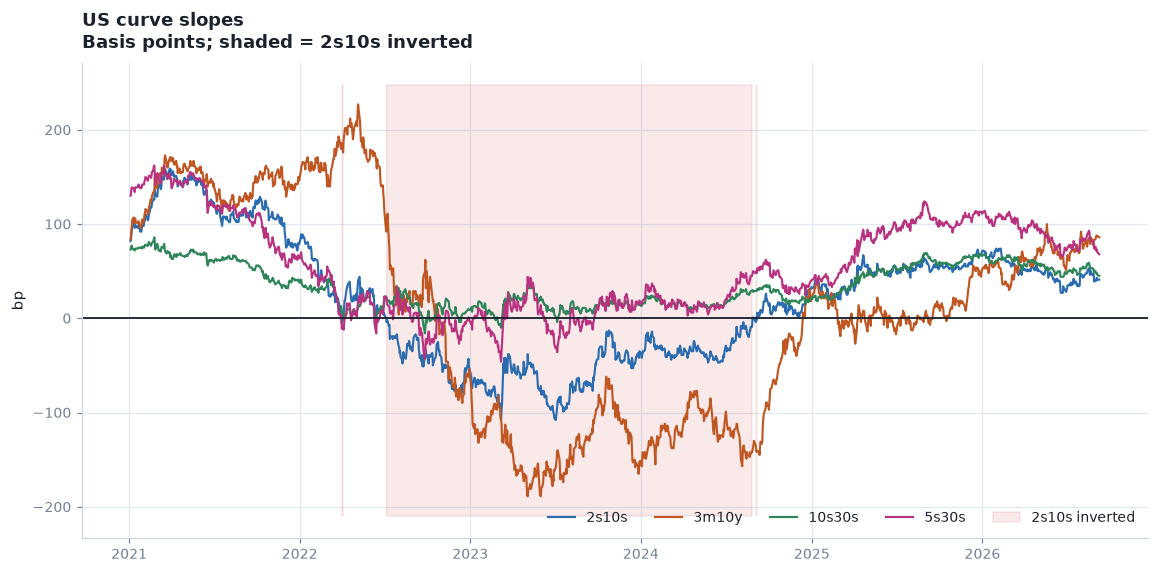

,now (bp),1m ago,1y ago,chg 1y (bp),inverted
2s10s,41.00,46.00,56.00,-15.00,False
3m10y,86.00,78.00,-5.00,91.00,False
10s30s,45.00,54.00,64.00,-19.00,False
5s30s,68.00,84.00,112.00,-44.00,False


2s10s inverted on 2 of the last 504 sessions (0%). Currently positively sloped.


In [4]:
slopes = {}
for name, (short, long) in config.CURVE_SLOPES.items():
    if short in curve.columns and long in curve.columns:
        slopes[name] = (curve[long] - curve[short]) * 100      # in bp
slopes = pd.DataFrame(slopes).dropna(how="all")

fig, ax = plt.subplots(figsize=(12.5, 5.6))
for i, c in enumerate(slopes.columns):
    ax.plot(slopes.index, slopes[c], lw=1.4, label=c, color=viz.PALETTE[i])
ax.axhline(0, color=viz.INK, lw=1.2)
inv = slopes["2s10s"] < 0 if "2s10s" in slopes else None
if inv is not None:
    ax.fill_between(slopes.index, ax.get_ylim()[0], ax.get_ylim()[1], where=inv.values,
                    color=viz.NEG, alpha=0.10, label="2s10s inverted")
viz.title(ax, "US curve slopes", "Basis points; shaded = 2s10s inverted")
ax.set_ylabel("bp"); ax.legend(ncol=5)
viz.save(fig, "03_curve_slopes"); plt.show()

slope_now = slopes.iloc[-1]
slope_tbl = pd.DataFrame({
    "now (bp)": slope_now,
    "1m ago": slopes.loc[:slopes.index[-1] - pd.Timedelta(days=30)].iloc[-1],
    "1y ago": slopes.loc[:slopes.index[-1] - pd.Timedelta(days=365)].iloc[-1],
})
slope_tbl["chg 1y (bp)"] = slope_tbl["now (bp)"] - slope_tbl["1y ago"]
slope_tbl["inverted"] = slope_tbl["now (bp)"] < 0
display(slope_tbl.round(1))

if inv is not None:
    days_inv = int(inv.tail(504).sum())
    print(f"2s10s inverted on {days_inv} of the last 504 sessions "
          f"({days_inv/504*100:.0f}%). Currently "
          f"{'INVERTED' if bool(inv.iloc[-1]) else 'positively sloped'}.")

## 3. Level, slope, curvature — a PCA of the curve

Yield curves move in three ways, and almost nothing else. Principal components on daily
yield *changes* recover them without being told to:

- **PC1 — level:** every tenor moves together (typically ~90% of variance)
- **PC2 — slope:** short and long ends move in opposite directions
- **PC3 — curvature:** the belly moves against both wings

If PC1 dominates, the market is repricing the whole policy path. When PC2's share rises,
it is repricing the *cycle* instead. Computed with numpy — `statsmodels` is not
installed and is not needed for an eigendecomposition.

Variance explained:  PC1 81.0%  PC2 11.2%  PC3 4.1%  PC4 1.6%
First three together: 96.2%


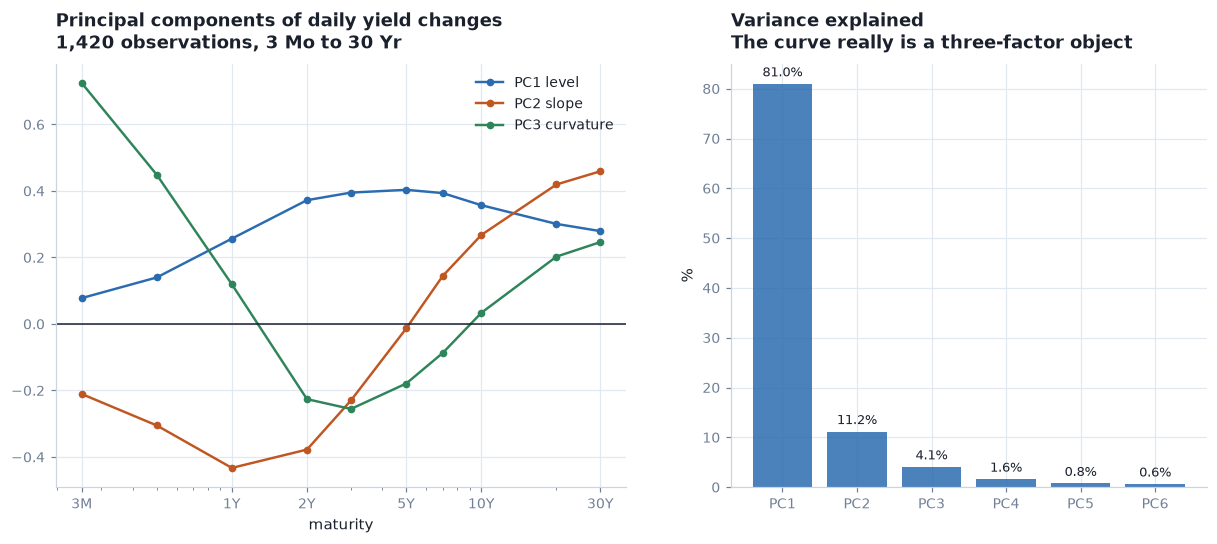

,PC1 level,PC2 slope,PC3 curvature
3 Mo,0.08,-0.21,0.72
6 Mo,0.14,-0.30,0.45
1 Yr,0.26,-0.43,0.12
2 Yr,0.37,-0.38,-0.23
3 Yr,0.40,-0.23,-0.26
5 Yr,0.40,-0.01,-0.18
7 Yr,0.39,0.14,-0.09
10 Yr,0.36,0.27,0.03
20 Yr,0.30,0.42,0.20
30 Yr,0.28,0.46,0.25


In [5]:
core = [t for t in ["3 Mo", "6 Mo", "1 Yr", "2 Yr", "3 Yr", "5 Yr",
                    "7 Yr", "10 Yr", "20 Yr", "30 Yr"] if t in curve.columns]
d = curve[core].dropna()
chg = d.diff().dropna() * 100                     # daily changes in bp

X = (chg - chg.mean()).values
cov = np.cov(X, rowvar=False)
evals, evecs = np.linalg.eigh(cov)
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]
explained = evals / evals.sum() * 100

pcs = pd.DataFrame(evecs[:, :3], index=core, columns=["PC1 level", "PC2 slope", "PC3 curvature"])
# Sign convention: a positive PC1 should mean yields rising.
for c in pcs.columns:
    if pcs[c].sum() < 0 and c == "PC1 level":
        pcs[c] = -pcs[c]

print("Variance explained:  " + "  ".join(
    f"PC{i+1} {explained[i]:.1f}%" for i in range(4)))
print(f"First three together: {explained[:3].sum():.1f}%")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 5),
                             gridspec_kw={"width_ratios": [1.2, 1]})
for c in pcs.columns:
    a1.plot([config.TENOR_YEARS[t] for t in core], pcs[c], marker="o", ms=4, label=c)
a1.axhline(0, color=viz.INK, lw=1); a1.set_xscale("log")
a1.set_xticks([0.25, 1, 2, 5, 10, 30]); a1.set_xticklabels(["3M", "1Y", "2Y", "5Y", "10Y", "30Y"])
viz.title(a1, "Principal components of daily yield changes",
          f"{len(chg):,} observations, {core[0]} to {core[-1]}")
a1.set_xlabel("maturity"); a1.legend()

a2.bar(range(6), explained[:6], color=viz.PALETTE[0], alpha=0.85)
for i in range(6):
    a2.text(i, explained[i] + 1.5, f"{explained[i]:.1f}%", ha="center", fontsize=8.5)
a2.set_xticks(range(6)); a2.set_xticklabels([f"PC{i+1}" for i in range(6)])
viz.title(a2, "Variance explained", "The curve really is a three-factor object")
a2.set_ylabel("%")
viz.save(fig, "03_curve_pca"); plt.show()
display(pcs.round(3))

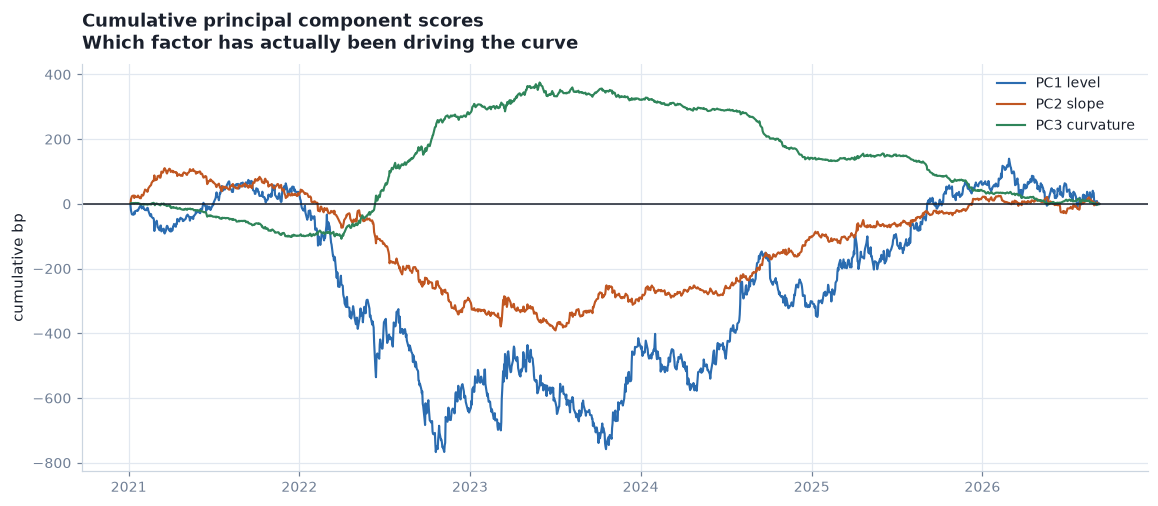

Share of the last 6 months' curve variance, by factor:


,% of variance
PC1 level,83.10
PC2 slope,10.80
PC3 curvature,2.70


In [6]:
scores = pd.DataFrame(X @ evecs[:, :3], index=chg.index,
                      columns=["PC1 level", "PC2 slope", "PC3 curvature"]).cumsum()
fig, ax = plt.subplots(figsize=(12.5, 4.8))
for c in scores.columns:
    ax.plot(scores.index, scores[c], lw=1.4, label=c)
ax.axhline(0, color=viz.INK, lw=1)
viz.title(ax, "Cumulative principal component scores",
          "Which factor has actually been driving the curve")
ax.legend(); ax.set_ylabel("cumulative bp")
viz.save(fig, "03_pca_scores"); plt.show()

proj = chg.tail(126).values @ evecs
recent_share = pd.Series(proj[:, :3].var(axis=0) / proj.var(axis=0).sum() * 100,
                         index=scores.columns)
print("Share of the last 6 months' curve variance, by factor:")
display(recent_share.round(1).to_frame("% of variance"))

## 4. Rate volatility regime — MOVE

MOVE is to bonds what VIX is to equities. It governs how much weight any duration signal
deserves: a clean-looking curve signal in a high-MOVE regime is far less reliable,
because the curve itself is being repriced violently.

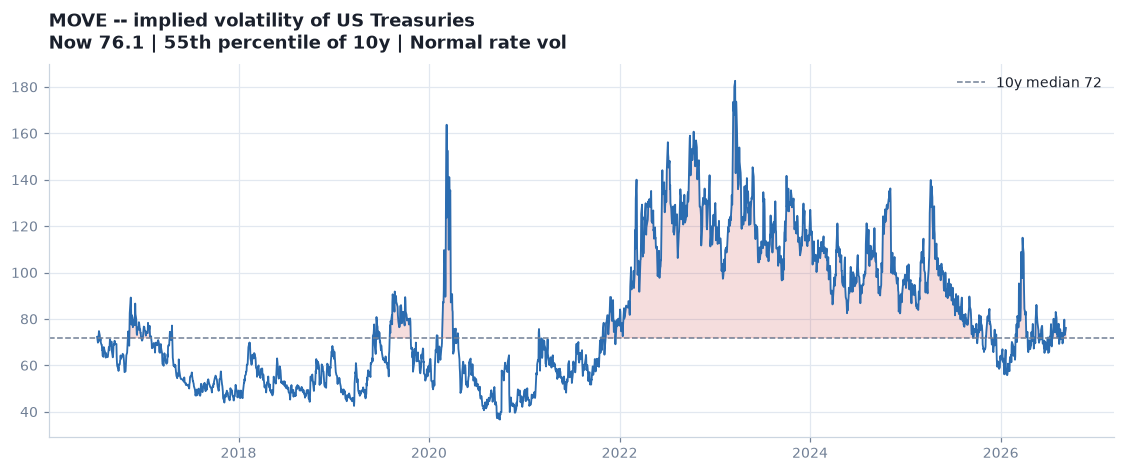

MOVE 76.1 | z -0.13 | percentile 55 -> Normal rate vol
as of 2026-09-08


In [7]:
move = fetch.price_history("^MOVE", period=config.LONG_HISTORY_PERIOD)["Close"].dropna()
move_hist = move.tail(2520)
move_pct = ind.percentile_rank(move_hist)
move_z = float((move.iloc[-1] - move_hist.mean()) / move_hist.std())
move_regime = ("High rate vol" if move_pct >= 70 else
               "Low rate vol" if move_pct <= 30 else "Normal rate vol")

fig, ax = plt.subplots(figsize=(12.5, 4.4))
ax.plot(move_hist.index, move_hist.values, color=viz.PALETTE[0], lw=1.2)
ax.axhline(move_hist.median(), color=viz.MUTED, ls="--", lw=1,
           label=f"10y median {move_hist.median():.0f}")
ax.fill_between(move_hist.index, move_hist.median(), move_hist.values,
                where=(move_hist.values > move_hist.median()),
                color=viz.NEG, alpha=0.16, interpolate=True)
viz.title(ax, "MOVE -- implied volatility of US Treasuries",
          f"Now {move.iloc[-1]:.1f} | {move_pct:.0f}th percentile of 10y | {move_regime}")
ax.legend()
viz.save(fig, "03_move"); plt.show()
print(f"MOVE {move.iloc[-1]:.1f} | z {move_z:+.2f} | percentile {move_pct:.0f} -> {move_regime}")
print(f"as of {move.index[-1].date()}")

## 5. The India leg

Seven NSE G-Sec indices, read two ways.

**Total-return indices** (`NIFTY 4-8 YR`, `8-13 YR`, `11-15 YR`, `15 YR AND ABOVE`)
include coupon carry, so a positive return does not by itself mean yields fell.

**The clean-price index** (`NIFTY 10 YR BENCHMARK G-SEC (CLEAN PRICE)`) strips accrued
interest, so its move is a price move — the cleanest available read on the direction of
the Indian 10-year yield.

From a price change, modified duration gives the implied yield change:

$$\Delta y \approx -\frac{\Delta P / P}{D_{mod}}$$

This yields a **change in basis points, not a level.** Treated as anything more than
that it would be false precision.

In [8]:
idx_all = fetch.nse_all_indices()
gsec = idx_all[idx_all["index"].isin(config.INDIA_BOND_INDICES)].copy()
gsec["duration"] = gsec["index"].map(config.INDIA_BOND_DURATION)
gsec = gsec[["index", "last", "percentChange", "perChange30d", "perChange365d", "duration"]]

# Carry approximation: total-return indices earn roughly the running yield over
# the period; the clean-price index does not, so it needs no adjustment.
ASSUMED_CARRY_YIELD = 6.5      # % -- typical Indian G-Sec running yield
gsec["is_clean_price"] = gsec["index"].str.contains("CLEAN PRICE")

def implied_dy_bp(row, ret_col, days):
    ret = row[ret_col]
    dur = row["duration"]
    if not np.isfinite(ret) or not np.isfinite(dur) or dur == 0:
        return np.nan
    carry = 0.0 if row["is_clean_price"] else ASSUMED_CARRY_YIELD * days / 365
    return -((ret - carry) / dur) * 100

gsec["implied dy 30d (bp)"] = gsec.apply(implied_dy_bp, axis=1, ret_col="perChange30d", days=30)
gsec["implied dy 1y (bp)"] = gsec.apply(implied_dy_bp, axis=1, ret_col="perChange365d", days=365)
display(gsec.set_index("index").round(2))
print(f"NSE as of {idx_all.attrs['as_of']}")

,last,percentChange,perChange30d,perChange365d,duration,is_clean_price,implied dy 30d (bp),implied dy 1y (bp)
index,,,,,,,,
NIFTY 8-13 YR G-SEC,"3,045.31",0.00,-0.57,3.85,10.50,False,10.52,25.24
NIFTY 10 YR BENCHMARK G-SEC,"2,665.76",0.00,-0.67,2.70,10.00,False,12.04,38.00
NIFTY 10 YR BENCHMARK G-SEC (CLEAN PRICE),867.90,-0.02,-1.29,-3.97,NaN,True,NaN,NaN
NIFTY 4-8 YR G-SEC INDEX,"3,347.44",0.03,0.00,5.51,6.00,False,8.90,16.50
NIFTY 11-15 YR G-SEC INDEX,"3,374.43",-0.02,-0.40,5.00,13.00,False,7.19,11.54
NIFTY 15 YR AND ABOVE G-SEC INDEX,"3,533.55",-0.04,-1.20,2.53,18.00,False,9.63,22.06
NIFTY COMPOSITE G-SEC INDEX,"3,135.53",0.00,-0.59,4.02,9.00,False,12.49,27.56


NSE as of 2026-09-09 10:41:00


In [9]:
clean = gsec[gsec["is_clean_price"]]
if len(clean):
    r = clean.iloc[0]
    india_dy_30d = float(r["implied dy 30d (bp)"])
    india_dy_1y = float(r["implied dy 1y (bp)"])
    print("India 10Y, from the clean-price index (no carry adjustment needed):")
    print(f"  30-day price move {r['perChange30d']:+.2f}%  ->  implied yield change {india_dy_30d:+.0f} bp")
    print(f"  1-year price move {r['perChange365d']:+.2f}%  ->  implied yield change {india_dy_1y:+.0f} bp")
else:
    india_dy_30d = india_dy_1y = np.nan
    print("Clean-price index not available today.")

us10 = curve["10 Yr"].dropna()
us_dy_30d = float((us10.iloc[-1] - us10.loc[:us10.index[-1] - pd.Timedelta(days=30)].iloc[-1]) * 100)
us_dy_1y = float((us10.iloc[-1] - us10.loc[:us10.index[-1] - pd.Timedelta(days=365)].iloc[-1]) * 100)

cmp_tbl = pd.DataFrame({
    "US 10Y (actual yield chg, bp)": [us_dy_30d, us_dy_1y],
    "India 10Y (implied yield chg, bp)": [india_dy_30d, india_dy_1y],
}, index=["30 days", "1 year"])
cmp_tbl["divergence (bp)"] = (cmp_tbl["India 10Y (implied yield chg, bp)"]
                              - cmp_tbl["US 10Y (actual yield chg, bp)"])
display(cmp_tbl.round(0))
print("Positive divergence = Indian yields rose more (or fell less) than US yields.")
print("NOTE: these are CHANGES. No India yield level is published by the verified sources,")
print("      so no India-US spread level is computed here.")

India 10Y, from the clean-price index (no carry adjustment needed):
  30-day price move -1.29%  ->  implied yield change +nan bp
  1-year price move -3.97%  ->  implied yield change +nan bp


,"US 10Y (actual yield chg, bp)","India 10Y (implied yield chg, bp)",divergence (bp)
30 days,15.00,NaN,NaN
1 year,75.00,NaN,NaN


Positive divergence = Indian yields rose more (or fell less) than US yields.
NOTE: these are CHANGES. No India yield level is published by the verified sources,
      so no India-US spread level is computed here.


### The currency leg

Rate differentials and the rupee are two views of the same capital-flow question. When
US yields rise relative to India's, capital is paid more to sit in dollars, and the
rupee usually feels it.

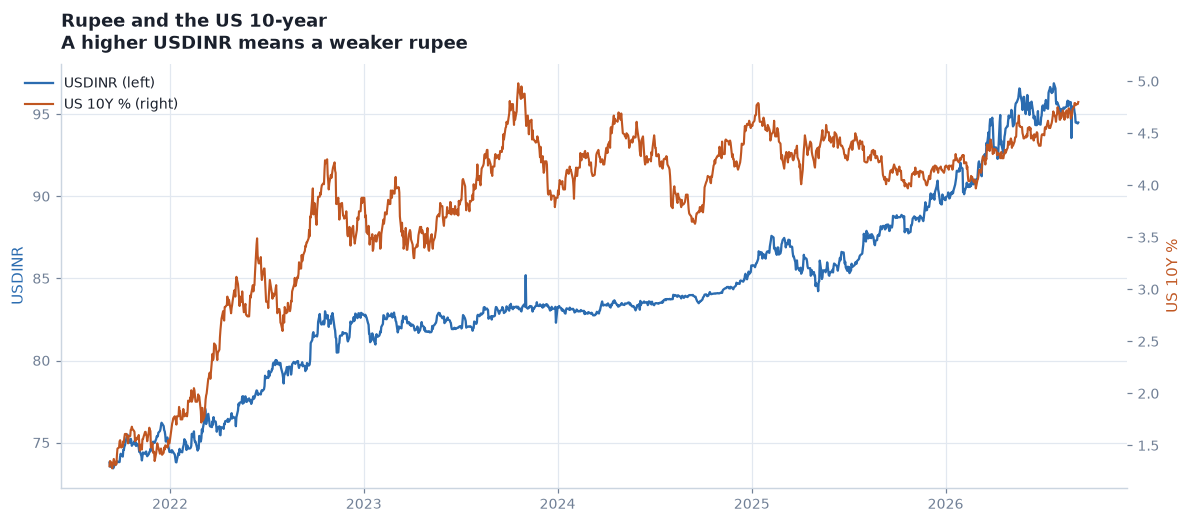

USDINR vs US 10Y -- level correlation +0.78, daily-change correlation +0.02
USDINR now 94.49 (as of 2026-09-08), 1y change +7.2%


In [10]:
inr = fetch.price_history("INR=X", period="5y")["Close"].dropna()
us10_5y = us10.tail(len(us10.loc[us10.index >= us10.index[-1] - pd.Timedelta(days=365*5)]))

pair = align.align_to_calendar(
    pd.DataFrame({"USDINR": inr, "US 10Y": us10_5y}), calendar="B", max_gap=3)
pair = pair.dropna()

fig, ax = plt.subplots(figsize=(12.5, 5))
ax.plot(pair.index, pair["USDINR"], color=viz.PALETTE[0], lw=1.5, label="USDINR (left)")
ax.set_ylabel("USDINR", color=viz.PALETTE[0])
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(pair.index, pair["US 10Y"], color=viz.PALETTE[1], lw=1.4, label="US 10Y % (right)")
ax2.set_ylabel("US 10Y %", color=viz.PALETTE[1])
viz.title(ax, "Rupee and the US 10-year",
          "A higher USDINR means a weaker rupee")
fig.legend(loc="upper left", bbox_to_anchor=(0.09, 0.88))
viz.save(fig, "03_inr_vs_us10y"); plt.show()

corr_lvl = float(pair["USDINR"].corr(pair["US 10Y"]))
corr_chg = float(pair["USDINR"].pct_change().corr(pair["US 10Y"].diff()))
print(f"USDINR vs US 10Y -- level correlation {corr_lvl:+.2f}, daily-change correlation {corr_chg:+.2f}")
print(f"USDINR now {pair['USDINR'].iloc[-1]:.2f} (as of {pair.index[-1].date()}), "
      f"1y change {ind.trailing_return(pair['USDINR'], 365):+.1f}%")

## 6. Rate regime and duration signal

Three inputs, each with an explicit rule:

1. **Curve direction** — is 2s10s steepening or flattening over 3 months?
2. **Level direction** — is the 10Y yield rising or falling over 3 months?
3. **Rate volatility** — MOVE's percentile, which scales confidence rather than direction.

Duration is attractive when yields are falling and volatility is contained; it is
dangerous when yields are rising into a high-MOVE regime.

In [11]:
s2s10 = slopes["2s10s"] if "2s10s" in slopes else pd.Series(dtype=float)
slope_chg_3m = float(s2s10.iloc[-1] - s2s10.loc[:s2s10.index[-1] - pd.Timedelta(days=91)].iloc[-1])
level_chg_3m = float((us10.iloc[-1] - us10.loc[:us10.index[-1] - pd.Timedelta(days=91)].iloc[-1]) * 100)

curve_dir = "steepening" if slope_chg_3m > 5 else "flattening" if slope_chg_3m < -5 else "flat"
level_dir = "rising" if level_chg_3m > 10 else "falling" if level_chg_3m < -10 else "range-bound"
inverted_now = bool(s2s10.iloc[-1] < 0)

if level_dir == "falling" and move_pct < 70:
    duration_signal = "Constructive on duration"
elif level_dir == "rising" and move_pct >= 70:
    duration_signal = "Avoid duration"
elif level_dir == "rising":
    duration_signal = "Cautious on duration"
else:
    duration_signal = "Neutral on duration"

rate_regime = f"10Y {level_dir}, curve {curve_dir}, {move_regime.lower()}"

summary = pd.DataFrame({
    "input": ["US 10Y level", "2s10s slope", "2s10s inverted?", "MOVE percentile",
              "India 10Y (implied)"],
    "reading": [f"{us10.iloc[-1]:.2f}%", f"{s2s10.iloc[-1]:+.0f} bp",
                "yes" if inverted_now else "no", f"{move_pct:.0f}",
                f"{india_dy_1y:+.0f} bp over 1y" if np.isfinite(india_dy_1y) else "n/a"],
    "3m change": [f"{level_chg_3m:+.0f} bp", f"{slope_chg_3m:+.0f} bp", "", "", ""],
    "reads as": [level_dir, curve_dir, "", move_regime, ""],
})
display(summary)
print(f"\nRATE REGIME:     {rate_regime}")
print(f"DURATION SIGNAL: {duration_signal}")

,input,reading,3m change,reads as
0,US 10Y level,4.80%,+27 bp,rising
1,2s10s slope,+41 bp,+1 bp,flat
2,2s10s inverted?,no,,
3,MOVE percentile,55,,Normal rate vol
4,India 10Y (implied),n/a,,



RATE REGIME:     10Y rising, curve flat, normal rate vol
DURATION SIGNAL: Cautious on duration


In [12]:
payload = {
    "signal": duration_signal,
    "score": round(-level_chg_3m / 100, 3),      # falling yields -> positive
    "as_of": str(curve.index[-1].date()),
    "regime": rate_regime,
    "us_curve": {t: round(float(curve[t].iloc[-1]), 3) for t in tenors},
    "us_10y_%": round(float(us10.iloc[-1]), 3),
    "slopes_bp": {k: round(float(v), 1) for k, v in slope_now.items()},
    "inverted_2s10s": inverted_now,
    "chg_3m_bp": {"level": round(level_chg_3m, 1), "2s10s": round(slope_chg_3m, 1)},
    "pca_variance_%": {f"PC{i+1}": round(float(explained[i]), 1) for i in range(3)},
    "move": {"level": round(float(move.iloc[-1]), 2), "pctile_10y": round(move_pct, 1),
             "regime": move_regime},
    "india_implied_dy_bp": {"30d": None if not np.isfinite(india_dy_30d) else round(india_dy_30d, 0),
                            "1y": None if not np.isfinite(india_dy_1y) else round(india_dy_1y, 0),
                            "method": "clean-price index / modified duration; CHANGE not level"},
    "usdinr": round(float(pair["USDINR"].iloc[-1]), 3),
}
dashboard.append("03_rates", payload)
display(dashboard.summary())

,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-38.36,2026-09-08,2026-09-08 11:47:51
4,05_india_market,Mixed,0.23,2026-09-08 15:30:00,2026-09-08 11:48:30
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",81.12,2026-09-08,2026-09-08 11:54:03
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 04:42:58
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 04:49:04
8,09_positioning,"12 names scored, 6 short candidates checked fo...",54.69,2026-09-09,2026-09-09 05:12:38
9,10_portfolio,"6L / 5S, gross 1.01x, net -0.13x",7.25,2026-09-09,2026-09-09 05:01:54


## What this hands to notebook 04

The rate regime is the discount rate under every equity valuation. Notebook 04 takes it
into the global equity comparison — US, Europe, Asia and LatAm — and ends on the one
relative-strength line that matters for everything after it: **India versus the world.**